In [1]:
%matplotlib widget

In [2]:
from pathlib import Path
from urllib import request

from astropy.io import fits
import numpy as np

import matplotlib.pyplot as plt

from ppxf.ppxf import ppxf, robust_sigma
import ppxf.ppxf_util as util
import ppxf.sps_util as lib
from ppxf.ppxf import losvd_rfft, rebin

import pandas as pd

### Function to iteratively clip the outliers

In [3]:
def clip_outliers(galaxy, bestfit, mask):
    """
    Repeat the fit after clipping bins deviants more than 3*sigma in relative
    error until the bad bins don't change any more. This function uses eq.(34)
    of Cappellari (2023) https://ui.adsabs.harvard.edu/abs/2023MNRAS.526.3273C
    """
    while True:
        scale = galaxy[mask] @ bestfit[mask]/np.sum(bestfit[mask]**2)
        resid = scale*bestfit[mask] - galaxy[mask]                   #Evaluate the residuals and the dispersion of them  
        err = robust_sigma(resid, zero=1)
        ok_old = mask
        mask = np.abs(bestfit - galaxy) < 3*err
        if np.array_equal(mask, ok_old):
            break
            
    return mask

### Function to fit the stellar kinematics without outliers

In [4]:
def ppxf_fit_and_clean(templates, galaxy, velscale, start, mask0, lam, lam_temp, plot=True, quiet=False):
    """
    This is a simple pPXF wrapper. It perform two pPXF fits: the first one
    serves to estimate the scatter in the spectrum and identify the outlier
    pixels. The second fit uses the mask obtained from the first fit to exclude
    the outliers. The general approach used in this function is described in
    Sec.6.5 of Cappellari (2023) https://ui.adsabs.harvard.edu/abs/2023MNRAS.526.3273C
    """
    mask = mask0.copy()     #Initial mask 
    pp = ppxf(templates, galaxy, np.ones_like(galaxy), velscale, start,      #Fit without the mask
              moments=2, degree=4, mdegree=-1, lam=lam, lam_temp=lam_temp,
              mask=mask, quiet=quiet)              

    if plot:
        plt.figure(figsize=(20, 3))
        plt.subplot(121)
        pp.plot()
        plt.title("Initial pPXF fit before outliers removal")

    mask = clip_outliers(galaxy, pp.bestfit, mask)

    # Add clipped pixels to the original masked emission lines regions and repeat the fit
    mask &= mask0     #To mask also the outliers together with the emission lines
    pp = ppxf(templates, galaxy, np.ones_like(galaxy), velscale, start,
              moments=2, degree=4, mdegree=-1, lam=lam, lam_temp=lam_temp,
              mask=mask, quiet=quiet)
    
    pp.optimal_template = templates.reshape(templates.shape[0], -1) @ pp.weights #Combined weighted templates to obtain the best template
    
    resid = (pp.galaxy - pp.bestfit)[pp.goodpixels]
    pp.sn = np.nanmedian(pp.galaxy[pp.goodpixels])/robust_sigma(resid)  #S/N of the residual spectrum (after the fit), only of the good pixels

    if plot:
        plt.subplot(122)
        pp.plot()
        plt.title("pPXF fit after outliers removal")

    return pp

In [5]:
wv, flux, error = np.loadtxt('Spectrum2s_3', unpack = True)
z = 0.0238 
wv_rf = wv/(1+z)
flux_rf = flux*(1+z)
error_rf = error*(1+z)

In [6]:
print(wv_rf, flux_rf, error_rf)

[4200.76186755 4202.20746239 4203.65305724 ... 6928.59933581 6930.04493065
 6931.49052549] [1.24110423 0.6844399  0.73636201 ... 0.74444204 0.79215134 0.81219613] [0.08701628 0.08566471 0.08706843 ... 0.02483017 0.02517781 0.0253084 ]


In [7]:
# sps_name = 'fsps'
# sps_name = 'galaxev'
sps_name = 'emiles'
# sps_name = 'xsl'

In [8]:
ppxf_dir = Path(lib.__file__).parent
basename = f"spectra_{sps_name}_9.0.npz"
filename = ppxf_dir / 'sps_models' / basename
if not filename.is_file():
    url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
    request.urlretrieve(url, filename)

In [9]:
c = 299792.458  # speed of light in km/s
velscale = np.min(c*np.diff(np.log(wv_rf))) #velocity scale to quantify the galaxy velocity dispersion
flux_rf_rebin, wv_rf_rebin, velscale = util.log_rebin(wv_rf, flux_rf, velscale = velscale) #We need to rebin the flux and the other things to work with the code
galaxy = flux_rf_rebin/np.median(flux_rf_rebin) #Normalization
error_rf_rebin, wv_rf_rebin, velscale = util.log_rebin(wv_rf, error_rf, velscale = velscale)
error_gal = error_rf_rebin/np.median(error_rf_rebin)

In [10]:
velscale

62.52964314399511

In [11]:
R = 2000 #risoluzione FORS2
fwhm_gal = (wv_rf/R)
print(fwhm_gal)

[2.10038093 2.10110373 2.10182653 ... 3.46429967 3.46502247 3.46574526]


In [12]:
fwhm_gal_dic = {"lam": wv_rf, "fwhm": fwhm_gal}
sps = lib.sps_lib(filename, velscale, fwhm_gal_dic)

(3343, 150)

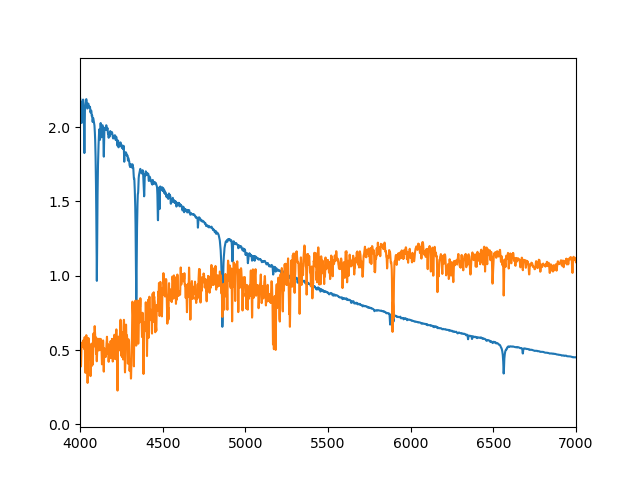

In [13]:
reg_dim = sps.templates.shape[1:]
stars_templates = sps.templates.reshape(sps.templates.shape[0], -1)
ln_lam_pop_stars = sps.ln_lam_temp

mask = (np.exp(ln_lam_pop_stars) > (np.min(wv_rf)-500))*(np.exp(ln_lam_pop_stars) < (np.max(wv_rf)+500))
stars_templates = stars_templates[mask, :]
lam_temp = sps.lam_temp
lam_temp = lam_temp[mask]

stars_templates /= np.median(stars_templates, axis=0)
ln_lam_pop_stars = ln_lam_pop_stars[mask]

plt.plot(np.exp(ln_lam_pop_stars), stars_templates[:, 0])
plt.plot(np.exp(ln_lam_pop_stars), stars_templates[:, -1])
plt.xlim(4000, 7000)
stars_templates.shape

In [14]:
np.mean(c*np.diff((ln_lam_pop_stars)))

62.529643143995116

In [15]:
stars_templates.shape

(3343, 150)

In [16]:
lam_range_temp = np.exp(sps.ln_lam_temp[[0, -1]])
mask0 = util.determine_mask(wv_rf_rebin, lam_range_temp, 0, width=1000)


#def determine_mask(ln_lam, lam_range_temp, redshift=0, width=800):
#    Generates a mask to avoid fitting the region possibly contaminated by a
#    given set of gas emission lines. This is meant to be used as input for pPXF.
#    Here ``mask = True`` for the pixels to include in the fit.
#
#    :param ln_lam: Natural logarithm np.log(wave) of the wavelength in
#        Angstrom of each pixel of the log rebinned *galaxy* spectrum.
#    :param lam_range_temp: Two elements vectors [lam_min_temp, lam_max_temp]
#        with the minimum and maximum wavelength in Angstrom in the stellar
#        *template* used in pPXF.
#    :param z: Estimate of the galaxy redshift.
#    :width: width of the emission line in km/s to mask it
#    :return: boolean vector mask to be used as input for pPXF

In [17]:
stars_templates.shape

(3343, 150)

In [18]:
sps.lam_temp.shape

(16269,)

 Best Fit:       Vel     sigma
 comp.  0:       -14        34
chi2/DOF: 0.003053; DOF: 2076; degree = 4; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/150
 Best Fit:       Vel     sigma
 comp.  0:       -15        46
chi2/DOF: 0.001953; DOF: 2007; degree = 4; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/150


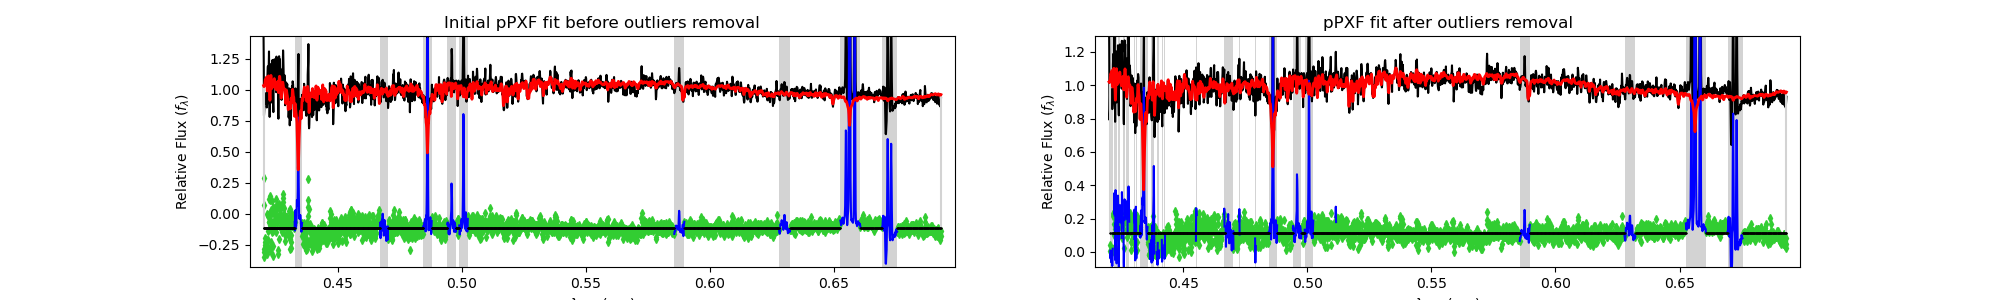

In [19]:
start = [20, 180.] 
pp_stars = ppxf_fit_and_clean(stars_templates, galaxy, velscale, start, mask0, np.exp(wv_rf_rebin), lam_temp)

In [20]:
pp_stars.sol

array([-14.87877502,  45.99560958])

## Fit with emission lines

In [21]:
tie_balmer = False  #Set this to ``True`` to tie the Balmer lines according to a theoretical decrement
limit_doublets = True #Set this to True to limit the ratio of the [OII] and [SII] doublets to the ranges allowed by atomic physics.

lam_range_gal = np.array([np.min(wv_rf), np.max(wv_rf)]) #Range of wv for the data
gas_templates, gas_names, line_wave = util.emission_lines(
    ln_lam_pop_stars, lam_range_gal, fwhm_gal_dic, tie_balmer=tie_balmer,
    limit_doublets=limit_doublets)

Emission lines included in gas templates:
['Hgamma' 'Hbeta' 'Halpha' '[SII]6731_d1' '[SII]6731_d2' 'HeII4687'
 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']


In [22]:
templates = np.column_stack([stars_templates, gas_templates])
start = [20, 180.] 
results = [pp_stars.sol[0], pp_stars.sol[1]]

In [23]:
n_temps = stars_templates.shape[1]
n_forbidden = np.sum(["[" in a for a in gas_names])  # forbidden lines contain "[*]"
n_balmer = len(gas_names) - n_forbidden

In [24]:
component = [0]*n_temps + [1]*n_balmer + [2]*n_forbidden #When fitting more than one kinematic component, this keyword should contain the component number of each input template. 
                                                         #In principle, every template can belong to a different kinematic component.

gas_component = np.array(component) > 0  # gas_component=True for gas templates
                                         #Boolean vector, of the same size as component, set to True where the given component describes a gas emission line. 
                                         #If given, pPXF provides the pp.gas_flux and pp.gas_flux_error in output.

In [25]:
moments = [2, 2, 2]
start = [results, start, start]
gas_reddening = 0 if tie_balmer else None

In [26]:
pp = ppxf(templates, galaxy, error_gal, velscale, start, moments=moments,     #We put what we had set here to do the ppxf procedure
          degree=7, mdegree=-1, lam=np.exp(wv_rf_rebin), lam_temp=np.exp(ln_lam_pop_stars), component=component,
          gas_component=gas_component, gas_names=gas_names,
          gas_reddening=gas_reddening)
#print(f"Elapsed time in pPXF: {(clock() - t):.2f}")

 Best Fit:       Vel     sigma
 comp.  0:       -20        47
 comp.  1:       -18        37
 comp.  2:       -15        30
chi2/DOF: 0.001928; DOF: 2396; degree = 7; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 37; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 12/160
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1                Hgamma      2.351       3.8     -18    37
Comp:  1                 Hbeta      4.880       2.8     -18    37
Comp:  1                Halpha      17.18       2.9     -18    37
Comp:  1          [SII]6731_d1      1.219       4.4     -18    37
Comp:  1          [SII]6731_d2      2.679       4.6     -18    37
Comp:  2              HeII4687      0.000       2.8     -15    30
Comp:  2               HeI5876     0.4350       1.9     -15    30
Comp:  2          [OIII]5007_d      4.047    

Ricordati che i d contengono il flusso di entrambi i doppietti.

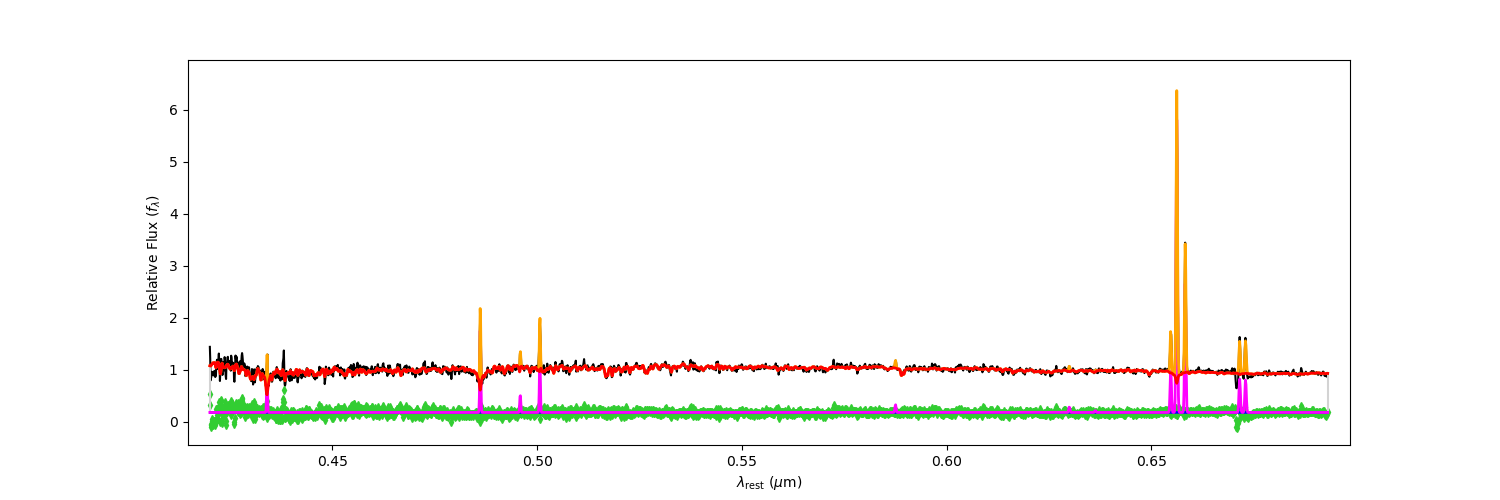

In [27]:
plt.figure(figsize=(15, 5))
pp.plot()

### Conversion from ergs/(cm^2 s A) to ergs/(cm^2 s)

In [28]:
rms = robust_sigma(galaxy - pp.bestfit, zero=1)
real_flux = np.zeros(len(gas_names))
dlam = np.zeros(len(gas_names))
for kk in range(len(gas_names)):
    dlam[kk] = line_wave[kk]*velscale/c  # Angstrom per pixel at line wavelength (dlam/lam = dv/c)
    real_flux[kk] = (pp.gas_flux[kk]*dlam[kk])  # Convert to ergs/(cm^2 s)
    an = np.max(pp.gas_bestfit_templates[:, kk])/rms
    print(f"{gas_names[kk]:12s} - Amplitude/Noise: {an:6.4g}; gas flux: {real_flux[kk]:6.0f} ergs/(cm^2 s)")

Hgamma       - Amplitude/Noise:  17.34; gas flux:      2 ergs/(cm^2 s)
Hbeta        - Amplitude/Noise:  35.36; gas flux:      5 ergs/(cm^2 s)
Halpha       - Amplitude/Noise:  126.8; gas flux:     24 ergs/(cm^2 s)
[SII]6731_d1 - Amplitude/Noise:  6.112; gas flux:      2 ergs/(cm^2 s)
[SII]6731_d2 - Amplitude/Noise:  11.67; gas flux:      4 ergs/(cm^2 s)
HeII4687     - Amplitude/Noise:     -0; gas flux:      0 ergs/(cm^2 s)
HeI5876      - Amplitude/Noise:  3.315; gas flux:      1 ergs/(cm^2 s)
[OIII]5007_d - Amplitude/Noise:  22.66; gas flux:      4 ergs/(cm^2 s)
[OI]6300_d   - Amplitude/Noise:  2.284; gas flux:      1 ergs/(cm^2 s)
[NII]6583_d  - Amplitude/Noise:  55.72; gas flux:     13 ergs/(cm^2 s)


### Bootstrapping to find the real errors

In [29]:
def bootstrap_residuals(model, resid, wild=True):
    """
    https://en.wikipedia.org/wiki/Bootstrapping_(statistics)#Resampling_residuals
    https://en.wikipedia.org/wiki/Bootstrapping_(statistics)#Wild_bootstrap

    Davidson & Flachaire (2008) eq.(12) gives the recommended form
    of the wild bootstrapping probability used here.

    https://doi.org/10.1016/j.jeconom.2008.08.003

    :param spec: model (e.g. best fitting spectrum)
    :param res: residuals (best_fit - observed)
    :param wild: use wild bootstrap to allow for variable errors
    :return: new model with bootstrapped residuals

    """
    if wild:    # Wild Bootstrapping: generates -resid or resid with prob=1/2
        eps = resid*(2*np.random.randint(2, size=resid.size) - 1)
    else:       # Standard Bootstrapping: random selection with repetition
        eps = np.random.choice(resid, size=resid.size)

    return model + eps

In [30]:
bestfit0 = pp.bestfit.copy()
resid = galaxy - bestfit0
start = pp.sol.copy()

 Best Fit:       Vel     sigma
 comp.  0:       -18        23
 comp.  1:       -17        37
 comp.  2:       -13        31
chi2/DOF: 0.001884; DOF: 2396; degree = 7; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 16; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 15/160
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
gas_component           name        flux       err      V     sig
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Comp:  1                Hgamma      2.077       3.8     -17    37
Comp:  1                 Hbeta      5.139       2.8     -17    37
Comp:  1                Halpha      17.16       2.9     -17    37
Comp:  1          [SII]6731_d1      1.553       4.4     -17    37
Comp:  1          [SII]6731_d2      2.229       4.6     -17    37
Comp:  2              HeII4687      0.000       2.8     -13    31
Comp:  2               HeI5876     0.4616       1.9     -13    31
Comp:  2          [OIII]5007_d      3.922    

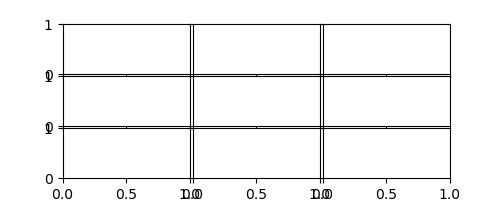

In [31]:
np.random.seed(123)

plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5, 2))
plt.subplots_adjust(hspace=0.04)
plt.subplots_adjust(wspace=0.02)

nboot = 200
flux_i = np.empty((nboot, pp.gas_flux.size))
for j in range(nboot):

    galaxy1 = bootstrap_residuals(bestfit0, resid)

    pp_b = ppxf(templates, galaxy1, error_gal, velscale, start, moments=moments,     #We put what we had set here to do the ppxf procedure
          degree=7, mdegree=-1, lam=np.exp(wv_rf_rebin), lam_temp=np.exp(ln_lam_pop_stars), component=component,
          gas_component=gas_component, gas_names=gas_names,
          gas_reddening=gas_reddening, bias = 0)

    real_flux_b = np.zeros(len(gas_names))
    for kk in range(len(gas_names)):
        dlam = line_wave[kk]*velscale/c  # Angstrom per pixel at line wavelength (dlam/lam = dv/c)
        real_flux_b[kk] = (pp_b.gas_flux[kk]*dlam)
    flux_i[j] = real_flux_b

flux_err_boot = flux_i.std(axis=0)

In [32]:
def process_ppxf_results(pp, gas_names, spectrum_name="spectrum", output_dir="./"):
    """
    Automatizza l'elaborazione dei risultati PPXF
    
    Parameters:
    -----------
    pp : oggetto PPXF con risultati del fit
    gas_names : list, nomi delle righe/doppietti dal fit PPXF
    spectrum_name : str, nome base per i file di output
    output_dir : str, directory di output
    
    Returns:
    --------
    dict con i 3 DataFrame creati
    """
    
    # Configurazione doppietti - definisce come separare le righe
    doublet_config = {
        # Nome nel fit PPXF : [nome_riga_blu, nome_riga_rossa, rapporto_blu:rossa]
        '[OIII]5007_d': ['[OIII]4959', '[OIII]5007', '1:3'],  
        '[NII]6583_d': ['[NII]6548', '[NII]6583', '1:3'],       
        '[OI]6300_d': ['[OI]6300', '[OI]6364', '3:1'],        #blu forte, rosso debole (caso speciale)
     #   '[SII]6731_d1': '[SII]6716',
     #   '[SII]6731_d2': '[SII]6731'
    }
    
    def separate_doublet(flux_total, ratio_type):
        if ratio_type == '1:3':  
            flux_blue = flux_total * (1/4)
            flux_red = flux_total * (3/4)
        elif ratio_type == '3:1':  
            flux_blue = flux_total * (3/4)
            flux_red = flux_total * (1/4)
        else:
            raise ValueError(f"Ratio type {ratio_type} not supported")
        
        return flux_blue, flux_red
    
    # 2. DataFrame con righe separate  
    expanded_names = []
    expanded_fluxes = []
    expanded_errors = []
    
    for i, name in enumerate(gas_names):
        flux = real_flux[i]*np.median(flux_rf_rebin)
        error = flux_err_boot[i]*np.median(error_rf_rebin)
        
        if name in doublet_config:
            config = doublet_config[name]
            blue_name, red_name, ratio = config

            flux_blue, flux_red = separate_doublet(flux, ratio)
                
            expanded_names.extend([blue_name, red_name])
            expanded_fluxes.extend([flux_blue, flux_red])
            expanded_errors.extend([error, error])
            
        else:
            expanded_names.append(name)
            expanded_fluxes.append(flux)
            expanded_errors.append(error)
    
    df_expanded = pd.DataFrame({
        'Name': expanded_names,
        'Flux': expanded_fluxes,
        'Error_flux': expanded_errors})
    
    # Salva i file CSV
    output_files = {'expanded': f"{output_dir}/{spectrum_name}_gas_exp.csv", }
    df_expanded.to_csv(output_files['expanded'], index=False)

In [33]:
gas_names

array(['Hgamma', 'Hbeta', 'Halpha', '[SII]6731_d1', '[SII]6731_d2',
       'HeII4687', 'HeI5876', '[OIII]5007_d', '[OI]6300_d', '[NII]6583_d'],
      dtype='<U12')

In [34]:
d1 = {'Name': gas_names, 'Flux': real_flux*np.median(flux_rf_rebin), 'Error flux': flux_err_boot*np.median(error_rf_rebin)}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Spectrum2s_3_gas_ppxf.csv", index= False)

process_ppxf_results(pp, gas_names, spectrum_name="Spectrum2s_3", output_dir="./")

d3 = {'Component': [0, 1, 2], 'Vel': [pp.sol[0][0], pp.sol[1][0], pp.sol[2][0]], 'Sigma': [pp.sol[0][1], pp.sol[1][1], pp.sol[2][1]]}
df3 = pd.DataFrame(data=d3)
df3.to_csv("Spectrum2s_3_kin.csv", index= False)

In [36]:
read = pd.read_csv("Spectrum2s_3_gas_ppxf.csv")
print(read)
read2 = pd.read_csv("Spectrum2s_3_gas_exp.csv")
print(read2)

           Name       Flux  Error flux
0        Hgamma   1.838183    0.008355
1         Hbeta   4.273012    0.010600
2        Halpha  20.305848    0.006979
3  [SII]6731_d1   1.474792    0.017104
4  [SII]6731_d2   3.247972    0.018319
5      HeII4687   0.000000    0.002119
6       HeI5876   0.460432    0.001361
7  [OIII]5007_d   3.650315    0.008846
8    [OI]6300_d   0.474355    0.000818
9   [NII]6583_d  11.526410    0.005857
            Name       Flux  Error_flux
0         Hgamma   1.838183    0.008355
1          Hbeta   4.273012    0.010600
2         Halpha  20.305848    0.006979
3   [SII]6731_d1   1.474792    0.017104
4   [SII]6731_d2   3.247972    0.018319
5       HeII4687   0.000000    0.002119
6        HeI5876   0.460432    0.001361
7     [OIII]4959   0.912579    0.008846
8     [OIII]5007   2.737736    0.008846
9       [OI]6300   0.355766    0.000818
10      [OI]6364   0.118589    0.000818
11     [NII]6548   2.881602    0.005857
12     [NII]6583   8.644807    0.005857
